# **BDBio 2026 Workshop on LLMs in Genomics**


June 4, 2026

#### **General Instructions**

1. This notebook has two sections. The first section walks you through loading a pre-trained LLM, and using it for zero-shot inference. The second section works on fine-tuning a model.

2. Go to kaggle.com, log in using your email address, click on new notebook, and then click on 'import notebook' to upload the downloaded file (bdbioworkshop.ipynb).

3. In the Settings Options on the right panel, ensure that Internet access is enabled.

3. Questions within the notebook (in bold) are intended to be discussed within your respective groups.

4. If you get disconnected often, please share laptops with your group members and work on a shared notebook, and reach out to the instructors.


# **Part 1**
In this section, we will use a pretrained DNA language model to predict the impact of mutations with zeroshot learning. This tutorial has been adapted from a tutorial designed by Raphael Mourad at University Paul Sabatier / INRAE MIAT Lab Toulouse.


 *We will attempt to learn the difference in predicted effects between a wild type sequence and a mutated sequence (one that we know causes disease).*

 The underlying assumption is that reference genomes on which these models are trained (typically derived from healthy individuals), are depleted of deleterious variants. Consequently, models trained on these data are predisposed to assigning lower probabilities to harmful variants. This observation underpins the strategy of using the log-likelihood ratio (LLR) between two alleles to estimate their relative fitness (Benegas et al, 2024).

 We will use two strategies to compute variant effects: 1. Looking at the differences in latent space between a wild type sequence and a sequence with a mutation. 2. Computing the differences in log likelihood between wild type sequences and a sequence with a mutation.

#### **Some DNA language models**

DNA language models are a new and fast-moving field. The latest and greatest DNA language model is Evo2, published in the last year[https://www.science.org/doi/10.1126/science.ado9336]. Developed in an academia-industry collaboration, it is trained on more than 9 trillion base pairs from DNA sequences across the tree of life. It can be used to 1) generate new DNA sequence. 2) predict DNA function. 3) predict biological features of interest.

Below is a list of commonly-used genomic language models, to give you a sense for commonly used model architectures. Try connect what you see in the tables with the material covered in the morning talks.


| **Model** | **Pretraining Data** | **Parameters** | **Tokenizer** | **Architecture** | **Objective** | **Sequence Length** | **Embedding Type** | **Key Capabilities** |
|-----------|----------------------|----------------|---------------|------------------|---------------|---------------------|-------------------|----------------------|
| **DNABERT** | Human genome | ~110M | k-mer (3–6) | Transformer Encoder | MLM | 512 bp | Contextual embeddings | Promoter prediction, TFBS prediction, variant effect detection |
| **GENA-LM** | Human + multi-species | 1.3B | BPE (6-mer derived) | Transformer Decoder | Causal LM | 2k–36k bp | Contextual embeddings | Long-range genomic modeling, sparse attention |
| **Nucleotide Transformer** | Human, 1000 Genomes, multi-species | 500M–2.5B | k-mer | Transformer Encoder | MLM | 1k–4k bp | Contextual embeddings | Transfer learning, multi-species generalization |
| **Evo 2** | Bacteria, archaea, viruses, eukaryotes | ~1.5B–40B | Byte-level nucleotide | Hyena + Attention | Causal LM | Up to 1M bp | Contextual embeddings | Mutation effect prediction, genome generation, evolutionary modeling |
| **HyenaDNA** | Human genome, regulatory sequences | 70M–1B | Single nucleotide (1-mer) | Hyena (implicit convolution) | Causal LM | Up to 1M bp | Hierarchical contextual embeddings | Ultra-long context modeling |
| **GROVER** | Human genome | ~1.2B | BPE / subword genomic tokens | Transformer Encoder | MLM + supervised regression | 2,048 bp | Contextual + task-aware embeddings | Variant effect prediction, annotation transfer |
| **DNABERT-2** | Human + multi-species | 117M | BPE | Transformer Encoder | MLM | ~1k bp | Contextual embeddings | Efficient multi-species foundation model |
| **GPN** | *Arabidopsis* + Brassicales genomes | ~100M | Single nucleotide | Transformer Encoder | MLM | ~1k bp | Contextual embeddings | Functional constraint prediction, evolutionary conservation |
| **MegaDNA** | ~100K bacteriophage genomes | Not publicly emphasized | Nucleotide | Transformer Decoder | Causal LM | 96k bp | Hierarchical embeddings | Genome-scale autoregressive modeling |
| **CD-GPT** | Genomic + protein sequences | ~1B | BPE | Transformer Decoder | Causal LM | Not specified | Cross-modal embeddings | DNA–RNA–protein representation learning |
| **LucaOne** | 169k species (DNA, RNA, proteins) | 10B+ | Mixed biological tokens | Transformer | MLM | Long-context | Unified biological embeddings | Universal biomolecular foundation model |
| **Caduceus** | Human genome | 20M–225M | Single nucleotide | Mamba / State Space Model | MLM | Up to 1M bp | Equivariant embeddings | Reverse-complement-aware long-range modeling |
| **AlphaGenome** | Human functional genomics datasets (ENCODE, GTEx, FANTOM5, 4D Nucleome, etc.) | Not disclosed | Single nucleotide (1-mer) | CNN–Transformer hybrid encoder–decoder | Multi-task supervised learning | Up to 1M bp | Multi-resolution contextual embeddings | Regulatory variant interpretation, splicing prediction, gene expression prediction, chromatin accessibility, TF binding, 3D genome structure prediction |


**Abbreviations**:
- **MLM**: Masked Language Modeling
- **CLM**: Causal Language Modeling
- **SSM**: State-Space Model
- **BPE**: Byte Pair Encoding


#### **Getting the data we need**

We will download the models and some of the data we use from a GitHub repository.

In [ ]:
!git clone https://github.com/raphaelmourad/Mistral-DNA.git

#### Installing Packages

In [ ]:
!pip install transformers==4.41.0
!pip install Bio==1.7.1
!pip install peft==0.10.0

# LOOK AT GPU USAGE AND RAM
!nvidia-smi

Questions to think about:
**What is the GPU running?**

**What is the maximum memory available?**

**What is CUDA?**

CUDA (Compute Unified Device Architecture) is a collection of libraries and tools. It is NVIDIA's parallel computing platform and programming model that enables dramatic performance increases on operations like matrix multiplications by harnessing the power of GPU (Graphics Processing Unit) acceleration.

Libraries like PyTorch, TensorFlow use CUDA for GPU acceleration.


#### Importing the required libraries

In [ ]:
# IMPORT LIBRARIES
import torch                         # PyTorch library used for tensor operations and model training
import tensorflow as tf               # TensorFlow library, often used for DL workflows and GPU checks
import numpy as np                    # NumPy is used for numerical operations, arrays, and data manipulation
import scipy as sp                    # SciPy provides scientific computing tools such as statistics and optimisation
import transformers                   # Hugging Face Transformers library for loading and fine-tuning foundation models

import gzip                           # Used to open and read compressed .gz files
from Bio import SeqIO                 # Used to read and parse biological sequence files such as FASTA/FASTQ
import matplotlib.pyplot as plt       # Used for plotting graphs, training curves, and visualisations
 
from transformers import AutoTokenizer # Automatically loads the correct tokenizer for a pretrained model
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments # Tools for training, configuring, and stopping training early
from transformers import AutoModelForCausalLM, AutoConfig # Loads pretrained causal language models and their configurations

We will next configure PyTorch and the CUDA environment to optimize GPU memory usage and performance.

#### cuDNN benchmarking for faster GPU convolutions

In [ ]:
# One line about what it is doing
torch.backends.cudnn.benchmark=True
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32 "

### Loading the model

Now we will get to the actual model we will be loading in this tutorial (Mistral-DNA). The model we are using is a toy model that was derived from a much larger model (Mistral) by removing some layers, that make it possible to work with given the memory constraints. {Link}

Though the model we are using is downloaded from the git repository we cloned, many pre-trained models are found on a hub called HuggingFace (https://huggingface.co/models), and can directly be imported from there.

Look up the Mistral model and how it was built

1. **What data was used to train the model?**
2. **How many parameters does it have?**

Mistral-DNA was trained on DNA sequences of length 200 bp from the human reference genome. That means it isn't trained on any variant data, not on data from multiple species.

#### What are the limitations of using this toy example

#### Loading the tokenizer that we will use 

In [ ]:
model_name="RaphaelMourad/Mistral-DNA-v1-17M-hg38"
# LOAD TOKENIZER
tokenizer = transformers.AutoTokenizer.from_pretrained(
    model_name,
    #padding_side="left",
    use_fast=True,
    trust_remote_code=True,
)

tokenizer

**What tokenizer is used by the model?**

Mistral is not a DNA language model, but DNA language models commonly use k-mer tokens (most common) or byte-size encoding for tokenization. Evo2 uses byte-size tokenization.

*K-mer tokenization* groups nucleotides into overlapping 'k-mers', each of which is then used as a token. Typical k values range from 3 to 6.

**Assuming a k-mer of length k, how many possible tokens exists?**

K-mer tokenization can enable the detection of k-mers that are over-represented in certain parts of the genome.

*Byte-level tokenization or Byte pair encoding* This method of tokenization treats every base as a single token.


#### Loading the model

In [ ]:
# LOAD MODEL
model=transformers.AutoModelForCausalLM.from_pretrained(
      model_name,
  )
model.config.pad_token_id = tokenizer.pad_token_id
model


**What does the model look like?**

-How many layers does it contain?
-What are these layers?



#### Calculating number of parameters 

In [ ]:
# NUMBER OF MODEL PARAMETERS
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(f"Model size: {pytorch_total_params/1000**2:.1f}M parameters")


**Given the number of parameters in the model, how much memory is required to load it?**

We typically require 4 bytes per model (for 32-bit floating point).

This is only the memory required to store the model weights. If you are training a model, you may need as much as 20 extra bytes per parameter.

How much memory is consumed right now?

**How much memory would be required to work with the evo2 model?**

#### Using the model to estimate DNA sequence function

Let's create a random DNA sequence, tokenize it, and then compute its embedding.

#### Computing Sequence Embedding 

In [ ]:
# COMPUTE SEQUENCE EMBEDDING

#first tokenize the DNA string
dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
inputs = tokenizer(dna, return_tensors = 'pt')["input_ids"]
print(inputs)

hidden_states = model(inputs)[0].detach() # [1, sequence_length, 768]
print(hidden_states)

# embedding with mean pooling
embedding_mean = torch.mean(hidden_states[0], dim=0)
print(embedding_mean.shape) # expect to be 768

# embedding with max pooling
embedding_max = torch.max(hidden_states[0], dim=0)[0]
print(embedding_max.shape) # expect to be 768


**What does 'hidden states' contain?**

**What is the shape of 'hidden_states' and what does each dimension represent?**

**What is embedding with mean pooling versus with max pooling?**



In the code below, we estimate the variant effect for a known pathogenic variant, by computing the difference in embeddings between the wild-type sequence and the mutated sequence.



#### Computing Cystic fibrosis MUTATION EFFECT (GENE CFTR)


In [ ]:
# COMPUTE Cystic fibrosis MUTATION EFFECT (GENE CFTR)

dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT"
dna_mut="ATTAAAGAAAATATCATTGGTGTTTCCTAT"

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach() # [1, sequence_length, 768]

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalized)

**What kind of distance are we calculating?**


Now compare with a mutation that doesn't affect the DNA sequence.





In [ ]:
dna_wt= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATT = Isoleucine
dna_mut="ATAAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATA = Isoleucine

inputs_seqs = tokenizer([dna_wt,dna_mut], return_tensors = 'pt', padding=True)["input_ids"]
hidden_states_seqs = model(inputs_seqs)[0].detach() # [1, sequence_length, 768]

embedding_max = torch.max(hidden_states_seqs, dim=1)[0]
print(embedding_max)

distL2=torch.norm(embedding_max[0]-embedding_max[1])
print(distL2) # Mutation effect (unnormalized)

#### When you look at the two results above, does it make sense?

**If you change the model to a model with 1 million parameters instead of with 17 million parameters, how does model performance change?**

Check if there is such a model available in the files downloaded.

### Variant effect prediction using log likelihood

Another way to compute variant effects is to compute the *log likelihood ratio* between the reference sequence and the mutated sequence.




Let's do that for the two sequence pairs now.

We first write a function that returns the difference in log likelihood ratios given two sequences as input. Take a look at this function and see how it is different from the previous method.

In [ ]:
wild_type= "ATTAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATT = Isoleucine
mutated=   "ATAAAAGAAAATATCATCTTTGGTGTTTCCTAT" # ATA = Isoleucine

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model.to(device)

# Convert string tokens to numerical IDs
wt_tokens = tokenizer(wild_type, return_tensors = 'pt')["input_ids"]
mut_tokens = tokenizer(mutated, return_tensors = 'pt')["input_ids"]


wt_ids = torch.tensor(wt_tokens, dtype=torch.long)
mut_ids = torch.tensor(mut_tokens, dtype=torch.long)

model.eval()
with torch.no_grad():
    wt_output = model(wt_ids)
    mut_output = model(mut_ids)

    wt_logits = wt_output.logits
    mut_logits = mut_output.logits

print(wt_logits)
wt_logprobs = torch.log_softmax(wt_logits, dim=-1)
mut_logprobs = torch.log_softmax(mut_logits, dim=-1)

print(wt_logprobs)
wt_ll = wt_logprobs.gather(2, wt_ids.unsqueeze(-1)).squeeze(-1).sum().item()
mut_ll = mut_logprobs.gather(2, mut_ids.unsqueeze(-1)).squeeze(-1).sum().item()

delta_ll = mut_ll - wt_ll
print(delta_ll)


#Now repeat with the cystic fibrosis mutation. What do you see?

**What do you see when you look at the two likelihood scores? Are the results in line with what you expect?**

### Optional: Running over a set of sequences

You can skip this subsection and move on to part 2.

Now we will run the embedding over multiple pairs of sequences, and look at the distributions of scores across these pairs.

**Look at the output: is it in line with what you expect?**

In [ ]:
# FUNCTION TO COMPUTE EMBEDDING OF DNA SEQUENCES
def compEmbed(seq_list):
  inputs_seqs = tokenizer(seq_list, return_tensors = 'pt', padding=True)["input_ids"]
  hidden_states_seqs = model(inputs_seqs)[0].detach().cpu().numpy() # [1, sequence_length, 768]
  embedding_max = np.max(hidden_states_seqs, axis=1)
  return embedding_max

# FUNCTION TO COMPUTE THE MUTATION EFFECT
def compMutEffect(seq_ref_list,seq_alt_list):
  embedding_ref = compEmbed(seq_ref_list)
  embedding_alt = compEmbed(seq_alt_list)
  distL2=np.linalg.norm(embedding_alt-embedding_ref,axis=1,ord=2)
  return distL2

  # FUNCTION TO READ FASTA
def readRegularFastaFile(fasta_file):
	seql_list=[]
	with gzip.open(fasta_file, "rt") as handle:
			for record in SeqIO.parse(handle, "fasta"):
					seqj=str(record.seq)
					seql_list.append(seqj)
	return seql_list

In [ ]:
# LOAD SNPS AT EXONS AND SNPS AT INTRONS
win=201
file_SNPexon_ref="Mistral-DNA/data/SNP/SNPexon_ref_"+str(win)+"b.fasta.gz"
file_SNPexon_alt="Mistral-DNA/data/SNP/SNPexon_alt_"+str(win)+"b.fasta.gz"
file_SNPintron_ref="Mistral-DNA/data/SNP/SNPintron_ref_"+str(win)+"b.fasta.gz"
file_SNPintron_alt="Mistral-DNA/data/SNP/SNPintron_alt_"+str(win)+"b.fasta.gz"

kseq=100
exon_ref_seq=readRegularFastaFile(file_SNPexon_ref)[0:kseq]
exon_alt_seq=readRegularFastaFile(file_SNPexon_alt)[0:kseq]
intron_ref_seq=readRegularFastaFile(file_SNPintron_ref)[0:kseq]
intron_alt_seq=readRegularFastaFile(file_SNPintron_alt)[0:kseq]
print(len(exon_ref_seq))
exon_ref_seq[0:5]


In [ ]:
distL2_exonSNPs=compMutEffect(exon_ref_seq,exon_alt_seq)
distL2_intronSNPs=compMutEffect(intron_ref_seq,intron_alt_seq)
print(distL2_exonSNPs)

# BOXPLOT OF PREDICTED SNP EFFECTS
# We expect that the L2 distance is higher for SNPs that are expected to have a stronger effect (SNPs in exons) as compared to SNPs in introns
# However, due to the small size of the model, it might not be able to capture these motifs 
distL2SNPs = {'exonSNPs': distL2_exonSNPs, 'intronSNPs': distL2_intronSNPs}

fig, ax = plt.subplots()
ax.boxplot(distL2SNPs.values())
ax.set_xticklabels(distL2SNPs.keys())

### Results from running Evo

The model used in this workshop is a toy model used because of computational resource constraints. In the backend, we ran the same series of steps with a bigger model: evo. This is how the boxplot looked.

**Which results look better? Why do you think that is?**

To help you think about this: what is Evo trained on? How many parameters does it have? Are there things that could make evo run poorly for this question?

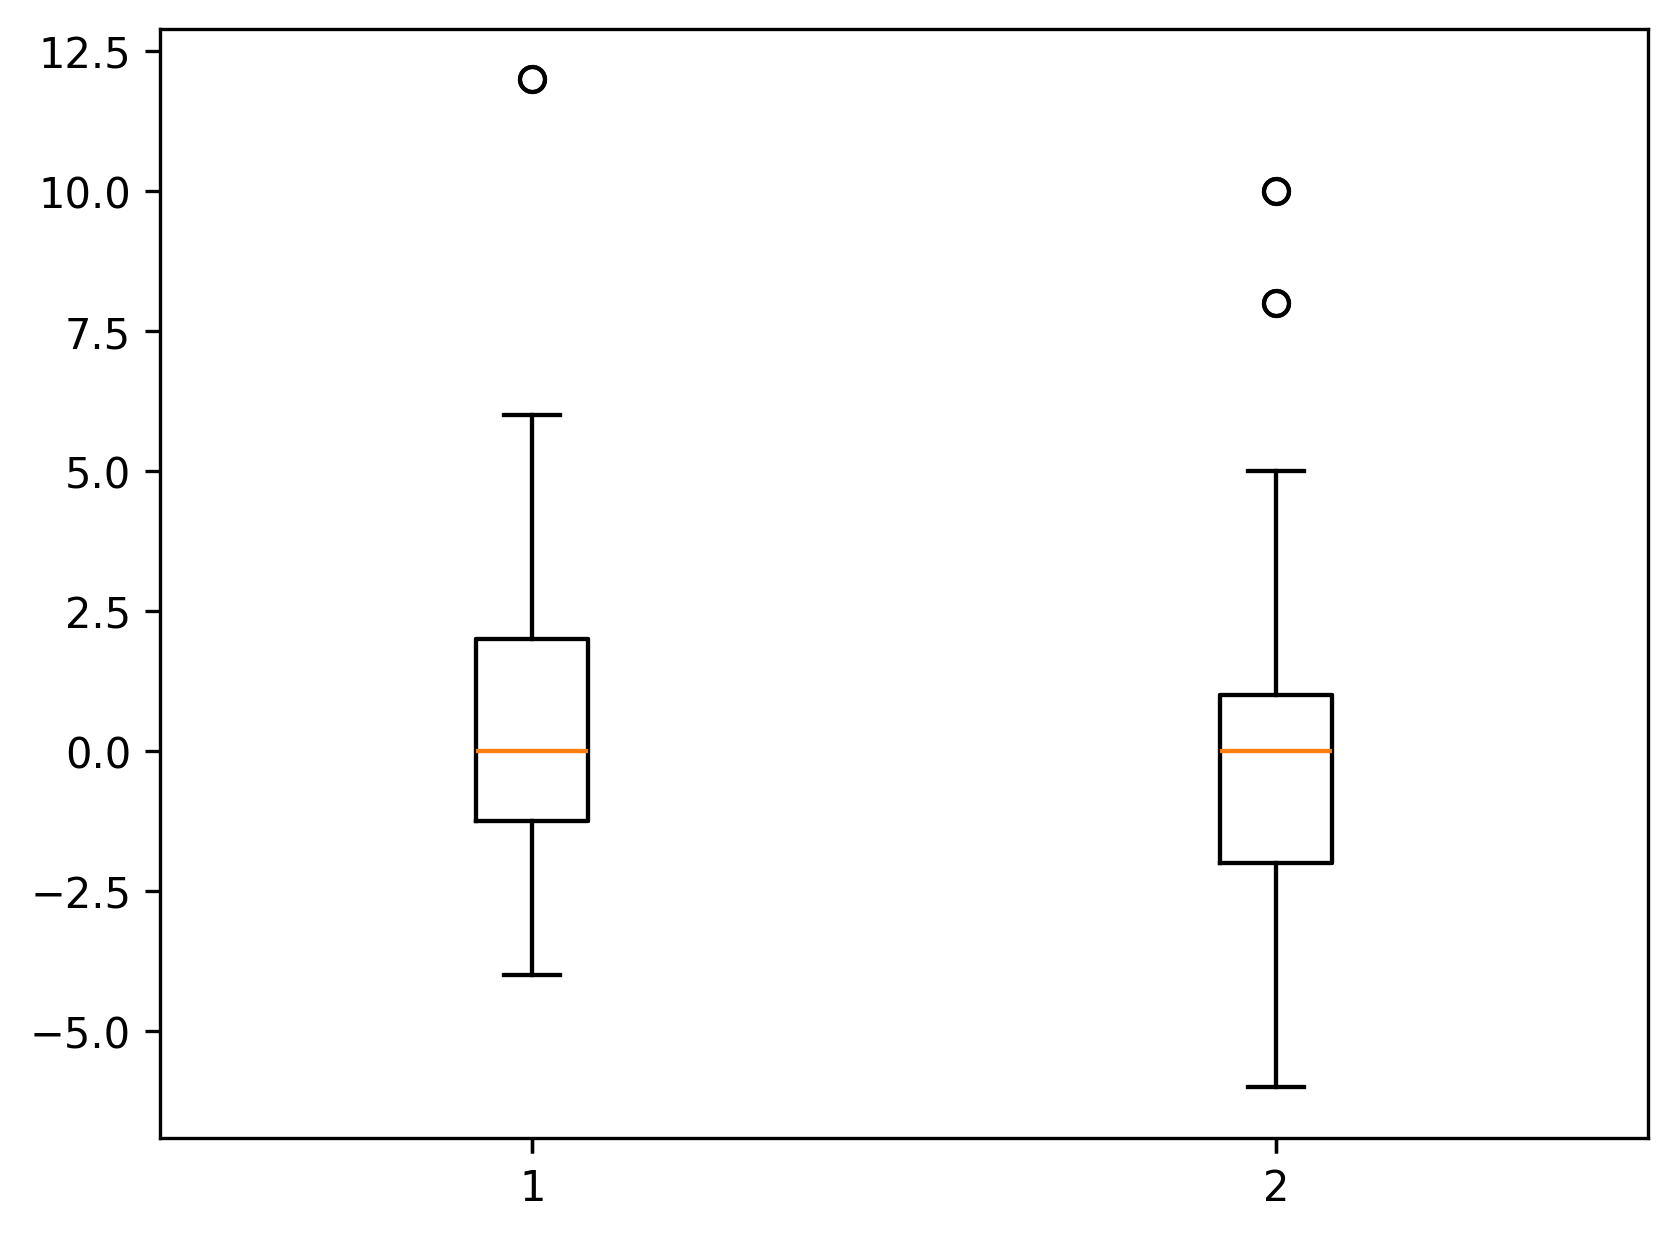



### Some questions to think about for DNA language models:

1. How does the size of the input DNA sequence affect the prediction? Play around with the sequence lengths of the input sequences to see how the scores change.

2. How does the maximum context length affect variant effect prediction? Does this depend on what exactly you are trying to predict?

3. What are some areas where you want to add protections to LLMs to prevent any responses from being shown? (akin to chatGPT saying "I cannot' tell you that in response to "How do we make a nuclear bomb?")

4. What are the features of genomes that make LLMs a good/bad technique to work on them?

### Another common application of LLMs in genomics

**scGPT** : A generative model trained on gene expression data from 33 million cells. This model can be used to predict cell type, genes important for each cell type, and perturbation responses.

In this model, each gene is a token, and each cell type/state is a 'sentence' of tokens.

A reference tutorial for scGPT can be tried out here: https://colab.research.google.com/github/bowang-lab/scGPT/blob/main/tutorials/zero-shot/Tutorial_ZeroShot_Reference_Mapping.ipynb


### NVIDIA Evo2-40B

#### What is NVIDIA Evo2-40B?

**Evo2-40B** is a large language model (LLM) developed by **NVIDIA** for bioinformatics and computational biology applications. It is part of the **Evo** family of models optimized for protein and genome-related tasks. The “40B” refers to the number of parameters (40 billion), making it a powerful model capable of performing complex sequence understanding, mutation effect prediction, structure-guided generation, and more.

Access - https://build.nvidia.com/arc/evo2-40b

---

#### NVIDIA Protein Design Blueprint

#### What is NVIDIA Protein Design Blueprint?

The **Protein Design Blueprint** by NVIDIA is a framework or ecosystem that combines large language models like **Evo2**, structure prediction tools, and simulation platforms to enable **end-to-end protein engineering**. It typically integrates tools like AlphaFold, BioNeMo, and molecular dynamics simulators to:

- Predict protein structures
- Optimize protein sequences
- Simulate protein dynamics
- Perform generative protein design

This blueprint is used in **drug discovery**, **synthetic biology**, and **therapeutic protein engineering**.

Access - https://build.nvidia.com/nvidia/evo2-protein-design
---

#### Different Parameters and How They Can Affect Performance

Here are some common parameters in models like Evo2-40B and Evo2 Protein Blueprint and how they can influence outcomes:

| Parameter              | Description                                     | Effect on Generation                                                                                                                                                                                                                                                                                                                                                                                                                                  |
|------------------------|-------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `sequence`             | Initial DNA sequence prompt                     | Basis for generation; influences continuity.                                                                                                                                                                                                                                                                                                                                                                                                         |
| `num_tokens`           | Number of tokens to generate                    | Controls output length. Adjust for the length of input—more tokens require greater computational capacity. Increasing token count beyond a point gives little benefit in terms of accuracy gains.                                                                                                                                                                                                                                                    |
| `temperature`          | Randomness control                              | Higher values generate more diverse outputs; lower values produce more deterministic results. Too low a value may result in repetitive or overly conservative outputs. Too high a value may produce highly unrealistic sequences.                                                                                                                                                                                                                   |
| `top_k`                | Top K token sampling                            | Limits choices to the top K tokens. When set to 1, only the most probable token is selected (more deterministic). When set to 0, all tokens are considered, increasing randomness. Other values select that many top tokens, controlling variation and maintaining a balance between creativity and realism.                                                                                                                                      |
| `top_p`                | Nucleus sampling threshold                      | Specifies a threshold (between 0 and 1) for nucleus sampling. The smallest set of tokens with cumulative probability exceeding this threshold is used, and the rest are filtered out. Setting this to 0.0 disables top-p sampling. Balances diversity and coherence in the output.                                                                                                                                                                |
| `enable_sampled_probs` | Enables probabilistic sampling                  | Introduces variability in the output by allowing sampling from the model’s probability distribution instead of always selecting the most likely token.                                                                                                                                                                                                                                                                                               |
| `enable_logits`        | Returns raw logits                              | Outputs the raw, pre-softmax scores (logits) for each token prediction. Useful for advanced users interested in analyzing token-level confidence or applying custom decision rules.                                                                                                                                                                                                                                                                |


#### Testing these interfaces

- Both webpages provide samples with standardised settings.
- You can try to run these sample scripts, use fasta sequences (only nucleotides) from the web, or your own custom sequences of A,T,C and G to test the model's abilites.
- You can also change the parameters to suit your needs. Every task has specific parameters that are the most suitable for it, shifting these parameters around can help you achieve better results, or balance between accuracy and computational cost

If youre interested in a more advanced look - https://docs.nvidia.com/bionemo-framework/2.5/user-guide/examples/bionemo-evo2/zeroshot_brca1/
(**NOTE :** This requires credits to run on the nvidia web interface, you can download the notebook from here - https://github.com/ArcInstitute/evo2/blob/main/notebooks/brca1/brca1_zero_shot_vep.ipynb for testing, note that not all systems can support the requirements)


### Other reading

1. I told AI to make me a protein. Here's what it came up with. https://www.nature.com/articles/d41586-025-01586-y
2. GPT outperforms experts at cell type identification: https://www.publichealth.columbia.edu/news/gpt-4-ai-outperforms-experts-identification-cell-types
3. A cool new startup generates AI-generated RNA-sequencing datasets: https://app.synthesize.bio/datasets/generate
4. Omni-DNA: A Unified Genomic Foundation Model for Cross-Modal and
Multi-Task Learning : https://arxiv.org/pdf/2502.03499
5. Generator: A Long-Context Generative Genomic Foundation Model :https://arxiv.org/pdf/2502.07272
6. PDLLMs: A group of tailored DNA large language
models for analyzing plant genomes : https://www.sciencedirect.com/science/article/pii/S1674205224003903  
7. There are some naysayers! "LLMs in genomics are misguided inefficient and scientifically wrong" https://medium.com/meta-multiomics/llms-in-genomics-are-misguided-inefficient-and-scientifically-wrong-e0da476ec9d3


# Part 2

# Task-Specific Fine-Tuning of Nucleotide Foundation Models: Understanding How to Fine-Tune and Apply Real-World Foundation Models


Now, in Part 2, we will move from simply using a pretrained model to actually adapting it for a real genomic prediction task. We will take the Nucleotide Transformer, attach a task-specific classification setup, and fine-tune it using LoRA, which allows us to train only a small number of additional parameters instead of updating the entire foundation model. This makes fine-tuning faster, cheaper, and more practical for biological datasets. We will apply this workflow to promoter and enhancer classification, and then evaluate the model using F1 score and MCC to understand how well it performs on unseen DNA sequences.

#### Installing the required packages 

In [ ]:
# Install
!pip install -q biopython transformers datasets huggingface_hub accelerate peft

If you're opening this notebook locally, make sure your environment has an install from the last version of those libraries.

To be able to share your model with the community and generate results like the one shown in the picture below via the inference API, there are a few more steps to follow.

First you have to login to the huggingface hub

Then you need to install Git-LFS. Uncomment the following instructions:

In [ ]:
!apt install git-lfs

#### Import and install required libraries 

In [ ]:
# Imports
from transformers import AutoTokenizer, AutoModelForMaskedLM, TrainingArguments, Trainer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import matthews_corrcoef, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from accelerate.test_utils.testing import get_backend

device, _, _ = get_backend()

### **Prepare and create the model for fine-tuning**

The nucleotide transformer will be fine-tuned on two **classification tasks**: promoter and enhancer types classification.
The `AutoModelForSequenceClassification` module automatically loads the model and adds a simple classification head on top of the final embeddings.

In [ ]:
num_labels_promoter = 2
# Load the model
model = AutoModelForSequenceClassification.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-human-ref", num_labels=num_labels_promoter)
model = model.to(device)

The LoRA parameters are now added to the model, and the parameters that will be finetuned are indicated.

#### What the parameters that will be finetuned?

In [ ]:
from peft import LoraConfig, TaskType

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, inference_mode=False, r=1, lora_alpha= 32, lora_dropout=0.1, target_modules= ["query", "value"],
    #modules_to_save=["intermediate"] # modules that are not frozen and updated during the training
)

#### Why this parameters ?
We choose a very small LoRA rank \(r=1\) so that the model can be fine-tuned with minimal memory and computation. The scaling factor `lora_alpha=32` makes this low-rank update strong enough to influence the model, while `lora_dropout=0.1` adds regularisation to reduce overfitting. We apply LoRA only to the `query` and `value` attention layers because these control how the transformer attends to DNA sequence patterns, making them a good lightweight target for task-specific adaptation.

##### What will happen if we change this parameters?

Now we convert the base classifier into a LoRA-powered PEFT model, so only a small number of adapter parameters will be trained while the original foundation model remains mostly frozen.

In [ ]:
from peft import get_peft_model

lora_classifier = get_peft_model(model, peft_config) # transform our classifier into a peft model
lora_classifier.print_trainable_parameters()
lora_classifier.to(device) # Put the model on the GPU

## **First task : Promoter prediction**

Promoter prediction is a **sequence classification** problem, in which the DNA sequence is predicted to be either a promoter or not.

A promoter is a region of DNA where transcription of a gene is initiated. Promoters are a vital component of expression vectors because they control the binding of RNA polymerase to DNA. RNA polymerase transcribes DNA to mRNA which is ultimately translated into a functional protein

 This task was introduced in [DeePromoter](https://www.frontiersin.org/articles/10.3389/fgene.2019.00286/full), where a set of TATA and non-TATA promoters was gathered. A negative sequence was generated from each promoter, by randomly sampling subsets of the sequence, to guarantee that some obvious motifs were present both in the positive and negative dataset.



### Dataset Loading and Preparation: Loading Known Promoter Sequences and Creating the Train-Test Split

In this step, we load the **promoter prediction dataset** from the Nucleotide Transformer downstream benchmark. The task name `promoter_all` tells the dataset loader that we want DNA sequences labelled according to whether they are promoters or non-promoters. The dataset is already provided in separate `train.parquet` and `test.parquet` files, so we directly load the training split for fine-tuning the model and the test split for evaluating how well the model generalises to unseen DNA sequences.

In [ ]:
from datasets import load_dataset
task = "promoter_all"

ds = load_dataset(
    "InstaDeepAI/nucleotide_transformer_downstream_tasks",
    data_files={
        "train": f"{task}/train.parquet",
        "test": f"{task}/test.parquet",
    },
)

train_dataset_promoter = ds["train"]
test_dataset_promoter = ds["test"]

In [ ]:
# Get training data
train_sequences_promoter = train_dataset_promoter['sequence']
train_labels_promoter = train_dataset_promoter['label']

# Split the dataset into a training and a validation dataset
train_sequences_promoter, validation_sequences_promoter, train_labels_promoter, validation_labels_promoter = train_test_split(train_sequences_promoter,
                                                                              train_labels_promoter, test_size=0.05, random_state=42)

# Get test data
test_sequences_promoter = test_dataset_promoter['sequence']
test_labels_promoter = test_dataset_promoter['label']

Let us have a look at the data. If we extract the last sequence of the dataset, we see that it is indeed a promoter, as its label is 1. Furthermore, we can also see that it is a TATA promoter, as the TATA motif is present at the 221th nucleotide of the sequence!

In [ ]:
idx_sequence = -1
sequence, label = train_sequences_promoter[idx_sequence], train_labels_promoter[idx_sequence]
print(f"The DNA sequence is {sequence}.")
print(f"Its associated label is label {label}.")

idx_TATA = sequence.find("TATA")

print(f"This promoter is a TATA promoter, as the TATA motif is present at the {idx_TATA}th nucleotide.")

### **Tokenizing the datasets**

All inputs to neural nets must be numerical. The process of converting strings into numerical indices suitable for a neural net is called **tokenization**.

In [ ]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-human-ref")

In [ ]:
from datasets import Dataset

# Promoter dataset
ds_train_promoter = Dataset.from_dict({"data": train_sequences_promoter,'labels':train_labels_promoter})
ds_validation_promoter = Dataset.from_dict({"data": validation_sequences_promoter,'labels':validation_labels_promoter})
ds_test_promoter = Dataset.from_dict({"data": test_sequences_promoter,'labels':test_labels_promoter})

In [ ]:
def tokenize_function(examples):
    outputs = tokenizer(examples["data"])
    return outputs

In [ ]:
# Creating tokenized promoter dataset
tokenized_datasets_train_promoter = ds_train_promoter.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)
tokenized_datasets_validation_promoter = ds_validation_promoter.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)
tokenized_datasets_test_promoter = ds_test_promoter.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)

Now, try inspecting the tokenised output yourself to see how the DNA sequence is converted into model-readable tokens.

### **Fine-tuning and evaluation**

We initialize our `TrainingArguments`. These control the various training hyperparameters, and will be passed to our `Trainer`.

The hyperparameters used for the IA³ method in the paper do not provide good performance for the LoRa method. Mainly, LoRA introduces more trainable parameters, therefore requiring a smaller learning rate. We here use a learning rate of 5.10⁻⁴, which enables us to get close to the [**paper's**](https://www.biorxiv.org/content/10.1101/2023.01.11.523679v1.full.pdf) performance.


Next, we define the metric we will use to evaluate our models and write a `compute_metrics` function. We can load this from the `scikit-learn` library.

Note that the finetuning is done with a small batch size (8). The training time can be reduced by increasing the batch size, as it leverages parallelism in the GPU.

In [ ]:
# NumPy is used here to manipulate logits and predictions
# after the model produces raw outputs.
import numpy as np

# f1_score is used to evaluate classification performance.
# Macro-F1 treats all classes equally, which is useful when classes are imbalanced.
from sklearn.metrics import f1_score

# Trainer and TrainingArguments provide the high-level Hugging Face training loop.
# DataCollatorWithPadding dynamically pads batches during training/evaluation.
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding


def compute_metrics_f1_score(eval_pred):
    """
    This function tells the Hugging Face Trainer how to compute evaluation metrics.

    The Trainer automatically passes model predictions and true labels
    to this function during evaluation.
    """

    # eval_pred contains two things:
    # 1. logits: raw model outputs before applying softmax/sigmoid
    # 2. labels: true target labels from the validation dataset
    logits, labels = eval_pred

    # Some transformer models return logits inside a tuple.
    # In that case, we only need the first element, which contains the actual logits.
    if isinstance(logits, tuple):
        logits = logits[0]

    # Case 1: Multi-class classification
    # If logits have shape [batch_size, num_classes],
    # we choose the class with the highest score.
    if logits.ndim == 2 and logits.shape[-1] > 1:
        predictions = np.argmax(logits, axis=-1)

    # Case 2: Binary classification with a single output value
    # If the model gives one logit per sample, values greater than 0
    # are assigned to class 1, otherwise class 0.
    else:
        predictions = (logits.reshape(-1) > 0).astype(int)

    # Return the evaluation metrics as a dictionary.
    # The keys will appear in the Trainer logs.
    return {
    "f1_score": f1_score(labels, predictions, average="macro"),

    # MCC stands for Matthews Correlation Coefficient.
    # It is especially useful for imbalanced classification problems.
    # Note: matthews_corrcoef should be imported before running this code.
    "mcc_score": matthews_corrcoef(labels, predictions)
}


# Batch size controls how many examples are processed at once on each GPU.
# A smaller batch size uses less GPU memory.
batch_size = 8

# This name is used to organise the output folders for checkpoints and saved models.
model_name = "nucleotide-transformer"


# TrainingArguments defines all major training settings:
# where to save outputs, how often to evaluate, learning rate, batch size,
# number of epochs, checkpointing behaviour, and logging.
args_promoter = TrainingArguments(
    # Folder where checkpoints and training outputs will be saved.
    output_dir=f"{model_name}-finetuned-lora-NucleotideTransformer",

    # Keeps all dataset columns.
    # This is often useful when working with custom models or PEFT models,
    # where the Trainer should not automatically remove columns.
    remove_unused_columns=False,

    # We evaluate the model every fixed number of training steps.
    eval_strategy="steps",

    # We also save checkpoints every fixed number of training steps.
    save_strategy="steps",

    # Run validation every 100 optimisation steps.
    eval_steps=100,

    # Save a checkpoint every 100 optimisation steps.
    save_steps=100,

    # Learning rate for updating the trainable LoRA adapter parameters.
    learning_rate=5e-4,

    # Number of training examples per GPU per step.
    per_device_train_batch_size=batch_size,

    # Gradient accumulation controls how many mini-batches are accumulated
    # before performing one optimiser update.
    # Here, 1 means we update after every batch.
    gradient_accumulation_steps=1,

    # Batch size used during evaluation.
    # This can often be larger than the training batch size because
    # evaluation does not require gradient storage.
    per_device_eval_batch_size=64,

    # Number of full passes over the training dataset.
    num_train_epochs=2,

    # Print training logs every 100 steps.
    logging_steps=100,

    # After training ends, automatically reload the best checkpoint.
    load_best_model_at_end=True,

    # The metric used to decide which checkpoint is the best.
    metric_for_best_model="f1_score",

    # Since higher F1 is better, this is set to True.
    greater_is_better=True,

    # Keep only one checkpoint to save disk space.
    # Since load_best_model_at_end=True, this keeps the best checkpoint.
    save_total_limit=1,

    # Explicitly tells the Trainer that the label column is called "labels".
    label_names=["labels"],

    # Drops the final incomplete batch if the dataset size is not divisible
    # by the batch size.
    dataloader_drop_last=True,

    # Stops training after 1000 optimisation steps, even if num_train_epochs
    # would allow more training.
    max_steps=1000,

    # Disables external logging tools such as Weights & Biases.
    report_to="none"
)


# The data collator prepares batches before they are given to the model.
# It dynamically pads sequences in each batch to the same length.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)


# Trainer combines the model, training settings, datasets,
# batching logic, and metric computation into a single training pipeline.
trainer = Trainer(
    # Move the model to the selected device, usually GPU if available.
    model=model.to(device),

    # Training configuration defined above.
    args=args_promoter,

    # Tokenised training dataset.
    train_dataset=tokenized_datasets_train_promoter,

    # Tokenised validation dataset used for evaluation.
    eval_dataset=tokenized_datasets_validation_promoter,

    # Handles dynamic padding during batching.
    data_collator=data_collator,

    # Custom evaluation function defined above.
    compute_metrics=compute_metrics_f1_score,
)


# Start the fine-tuning process.
# The Trainer will train, evaluate every 100 steps,
# save checkpoints, and track the best model using F1 score.
train_results = trainer.train()


# Save the best model loaded by load_best_model_at_end=True
# into a clean final folder.
trainer.save_model(f"{model_name}-best-promoter-model")

# Save the tokenizer in the same folder so that the model can be
# loaded and used later without redefining the tokenizer separately.
tokenizer.save_pretrained(f"{model_name}-best-promoter-model")

### **Validation F1 score**

In [ ]:
curve_evaluation_f1_score =[[a['step'],a['eval_f1_score']] for a in trainer.state.log_history if 'eval_f1_score' in a.keys()]
eval_f1_score = [c[1] for c in curve_evaluation_f1_score]
steps = [c[0] for c in curve_evaluation_f1_score]

In [ ]:
plt.plot(steps, eval_f1_score, 'b', label='Validation F1 score')
plt.title('Validation F1 score for promoter prediction')
plt.xlabel('Number of training steps performed')
plt.ylabel('Validation F1 score')
plt.legend()
plt.show()

### **F1 score on the test dataset**

In [ ]:
# Compute the F1 score on the test dataset :
print(f"F1 score on the test dataset: {trainer.predict(tokenized_datasets_test_promoter).metrics['test_f1_score']}")

#### For the promoter prediction task, we reproduced the experiment carried out in the [**article**](https://www.biorxiv.org/content/10.1101/2023.01.11.523679v1.full.pdf) by adapting the learning rate to the LoRa method. A F1 score of **0.937** is obtained after just **1000 training steps**. To get closer to the **0.954** score obtained in the nucleotide transformer paper after 10,000 training steps, we surely need to train for longer!

## **Second task : Enhancer prediction**

In this section, we fine-tune the nucleotide transformer model on **enhancer type prediction**, which consists in classifying a DNA sequence as **strong**, **weak** or **non enhancer**.

In genetics, an enhancer is a short (50–1500 bp) region of DNA that can be bound by proteins (activators) to increase the likelihood that transcription of a particular gene will occur.

[A deep learning framework for enhancer prediction using word embedding and sequence generation](https://www.sciencedirect.com/science/article/abs/pii/S0301462222000643) introduced the dataset used here by augmenting an original set of enhancers with 6000 synthetic enhancers and 6000 synthetic
non-enhancers produced through a generative model.

### **Dataset loading and preparation**

In [ ]:
from datasets import load_dataset

repo = "InstaDeepAI/nucleotide_transformer_downstream_tasks"
dataset_name = "enhancers_types"

ds_enhancers = load_dataset(
    repo,
    data_files={
        "train": f"{dataset_name}/train.parquet",
        "test": f"{dataset_name}/test.parquet",
    },
)

train_dataset_enhancers = ds_enhancers["train"]
test_dataset_enhancers = ds_enhancers["test"]

print(train_dataset_enhancers)
print(test_dataset_enhancers)
print(train_dataset_enhancers[0])

In [ ]:
# Get training data
train_sequences_enhancers = train_dataset_enhancers['sequence']
train_labels_enhancers = train_dataset_enhancers['label']

# Split the dataset into a training and a validation dataset
train_sequences_enhancers, validation_sequences_enhancers, train_labels_enhancers, validation_labels_enhancers = train_test_split(train_sequences_enhancers,
                                                                              train_labels_enhancers, test_size=0.10, random_state=42)

In [ ]:
# Get test data
test_sequences_enhancers = test_dataset_enhancers['sequence']
test_labels_enhancers = test_dataset_enhancers['label']

### **Tokenizing the datasets**

In [ ]:
# Enhancer dataset
ds_train_enhancers = Dataset.from_dict({"data": train_sequences_enhancers,'labels':train_labels_enhancers})
ds_validation_enhancers = Dataset.from_dict({"data": validation_sequences_enhancers,'labels':validation_labels_enhancers})
ds_test_enhancers = Dataset.from_dict({"data": test_sequences_enhancers,'labels':test_labels_enhancers})

In [ ]:
# Creating tokenized enhancer dataset
tokenized_datasets_train_enhancers = ds_train_enhancers.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)
tokenized_datasets_validation_enhancers = ds_validation_enhancers.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)
tokenized_datasets_test_enhancers = ds_test_enhancers.map(
    tokenize_function,
    batched=True,
    remove_columns=["data"],
)

### **Fine-tuning and evaluation**

In [ ]:
# Load the model
num_labels_enhancers = 3
model = AutoModelForSequenceClassification.from_pretrained("InstaDeepAI/nucleotide-transformer-500m-human-ref", num_labels=num_labels_enhancers)
model = model.to(device)

In [ ]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, inference_mode=False, r=1, lora_alpha= 32, lora_dropout=0.1, target_modules= ["query", "value"],
    #modules_to_save=["intermediate"] # modules that are not frozen and updated during the training
)

In [ ]:
lora_classifier = get_peft_model(model, peft_config) # transform our classifier into a peft model
lora_classifier.print_trainable_parameters()
lora_classifier.to(device) # Put the model on the GPU

We initialize our `TrainingArguments`. These control the various training hyperparameters, and will be passed to our `Trainer`.

We keep the same hyperparameters as for the promoter task, i.e the same as in the paper except for a learning rate of 5.10⁻⁴, which enables us to get close to [**paper's**](https://www.biorxiv.org/content/10.1101/2023.01.11.523679v1.full.pdf) performance.

In [ ]:
# NumPy is used to process the raw model outputs, called logits,
# and convert them into predicted class labels.
import numpy as np

# f1_score is used as the main evaluation metric.
# Macro-F1 is useful because it gives equal importance to each class.
from sklearn.metrics import f1_score

# Trainer provides a high-level training loop from Hugging Face.
# TrainingArguments stores the training configuration.
# DataCollatorWithPadding dynamically pads sequences inside each batch.
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding


def compute_metrics_f1_score(eval_pred):
    """
    This function defines the metrics that will be computed during validation.

    The Hugging Face Trainer automatically calls this function whenever
    evaluation is performed.
    """

    # eval_pred contains:
    # 1. logits: raw output scores produced by the model
    # 2. labels: ground-truth labels from the validation dataset
    logits, labels = eval_pred

    # Some transformer models return outputs as a tuple.
    # If that happens, the first element usually contains the logits.
    if isinstance(logits, tuple):
        logits = logits[0]

    # Multi-class classification case:
    # If logits have shape [batch_size, num_classes],
    # we choose the class with the largest logit value.
    if logits.ndim == 2 and logits.shape[-1] > 1:
        predictions = np.argmax(logits, axis=-1)

    # Binary classification case:
    # If the model outputs only one logit per example,
    # values greater than 0 are assigned to class 1,
    # and values less than or equal to 0 are assigned to class 0.
    else:
        predictions = (logits.reshape(-1) > 0).astype(int)

    # Return the metrics as a dictionary.
    # These metric names will appear in the Trainer logs.
    return {
    # Macro-F1 averages the F1 score across classes equally.
    # This is useful when the enhancer classes may be imbalanced.
    "f1_score": f1_score(labels, predictions, average="macro"),

    # MCC stands for Matthews Correlation Coefficient.
    # It measures the quality of binary or multi-class classification.
    # It is often more informative than accuracy for imbalanced datasets.
    "mcc_score": matthews_corrcoef(labels, predictions)
}


# Batch size controls how many examples are processed at once on each GPU.
# A smaller batch size reduces GPU memory usage.
batch_size = 8

# This name is used when creating folders for checkpoints and saved models.
model_name = "nucleotide-transformer"


# TrainingArguments contains the full training configuration for enhancer fine-tuning.
args_promoter = TrainingArguments(
    # Directory where model checkpoints and logs will be saved.
    output_dir=f"{model_name}-finetuned-lora-NucleotideTransformer",

    # Prevents the Trainer from automatically removing unused dataset columns.
    # This is helpful when using custom tokenised datasets or PEFT/LoRA models.
    remove_unused_columns=False,

    # Evaluate the model after a fixed number of training steps.
    eval_strategy="steps",

    # Save model checkpoints after a fixed number of training steps.
    save_strategy="steps",

    # Run validation every 100 optimisation steps.
    eval_steps=100,

    # Save a checkpoint every 100 optimisation steps.
    save_steps=100,

    # Learning rate used for fine-tuning.
    # In LoRA/PEFT, this mainly updates the small trainable adapter parameters.
    learning_rate=5e-4,

    # Number of training samples processed per GPU in one forward/backward pass.
    per_device_train_batch_size=batch_size,

    # Number of batches to accumulate before one optimiser update.
    # A value of 1 means the model updates after every batch.
    gradient_accumulation_steps=1,

    # Batch size used during validation.
    # Evaluation can usually use a larger batch size because gradients are not stored.
    per_device_eval_batch_size=64,

    # Number of full passes over the training dataset.
    num_train_epochs=2,

    # Print training progress every 100 steps.
    logging_steps=100,

    # At the end of training, reload the checkpoint with the best validation score.
    load_best_model_at_end=True,

    # Use validation F1 score to decide which checkpoint is best.
    metric_for_best_model="f1_score",

    # Higher F1 score means a better model.
    greater_is_better=True,

    # Keep only one checkpoint to save disk space.
    # Since load_best_model_at_end=True, this should retain the best checkpoint.
    save_total_limit=1,

    # Tells the Trainer that the label column in the dataset is called "labels".
    label_names=["labels"],

    # Drops the final batch if it is smaller than the specified batch size.
    # This can make batch shapes more consistent during training.
    dataloader_drop_last=True,

    # Stop training after 1000 optimisation steps.
    # This overrides longer training implied by num_train_epochs.
    max_steps=1000,

    # Disable external experiment tracking tools such as Weights & Biases.
    report_to="none"
)


# The data collator prepares batches before they are passed into the model.
# It dynamically pads DNA/token sequences in each batch to the same length.
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)


# The Trainer combines the model, datasets, training settings,
# padding logic, and evaluation metrics into one training pipeline.
trainer = Trainer(
    # Move the model to the selected device, usually GPU if available.
    model=model.to(device),

    # Training configuration defined above.
    args=args_promoter,

    # Tokenised enhancer training dataset.
    train_dataset=tokenized_datasets_train_enhancers,

    # Tokenised enhancer validation dataset.
    eval_dataset=tokenized_datasets_validation_enhancers,

    # Handles dynamic padding for every batch.
    data_collator=data_collator,

    # Metric function used during validation.
    compute_metrics=compute_metrics_f1_score,
)


# Start fine-tuning the nucleotide transformer on the enhancer dataset.
# During training, the model will be evaluated every 100 steps,
# checkpoints will be saved, and the best checkpoint will be selected using F1 score.
train_results = trainer.train()


# Save the best loaded model explicitly into a clean final folder.
# This makes it easy to reload the enhancer model later for inference.
trainer.save_model(f"{model_name}-best-enhancer-model")

# Save the tokenizer in the same folder as the model.
# This ensures the exact same tokenisation can be used during inference.
tokenizer.save_pretrained(f"{model_name}-best-enhancer-model")

Here, the metric used to evaluate the model is the Matthews Correlation Coefficient, which is more relevant than the accuracy when the classes in the dataset are unbalanced. We can load a predefined function from the `scikit-learn` library.

As with the first task, the time can be greatly reduced by increasing the batch size.

#### **Validation MCC score**

##### The validation MCC score measures how well the model predicts both classes, making it especially useful when the dataset is imbalanced.


In [ ]:
curve_evaluation_mcc_score = [
    [a['step'], a['eval_mcc_score']]
    for a in trainer.state.log_history
    if 'eval_mcc_score' in a
]

eval_mcc_score = [c[1] for c in curve_evaluation_mcc_score]
steps = [c[0] for c in curve_evaluation_mcc_score]

In [ ]:
plt.plot(steps, eval_mcc_score, 'b', label='Validation MCC score')
plt.title('Validation MCC score for enhancer prediction')
plt.xlabel('Number of training steps performed')
plt.ylabel('Validation MCC score')
plt.legend()
plt.show()

#### **MCC on the test dataset**

In [ ]:
# Compute the MCC score on the test dataset :
print(f"MCC score on the test dataset: {trainer.predict(tokenized_datasets_test_enhancers).metrics['test_mcc_score']}")